#Titanic Survival Analysis - Exploratory Data Analysis

The dataset brings data from the titanic catastrophe and the main goals of this project is to analyse if age, class, and sex influence the survival rate.

##Data Dictionary
Survived: 0=No, 1=Yes

Pclass: 1 = first class, 2 = second, 3 = third

SibSp: Number of brothers/partners on board. 0 = traveling alone,  otherwise, indicates the number of relatives on board

Parch: Number of parents/kids on board. 0 = no family, otherwise, indicates the number of relatives on board

Embarked: S = Southampton, C = Cherbourg, Q = Queenstown


In [24]:
#importing libraries and data used

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [25]:
#checking data frame

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



##Data Cleaning

In this stage, the dataset was analysed if there were any null cells using info() and isnull() functions, and the statistical summary of the numerical columns was obtained using the describe() function, including mean, standard deviation, and quartiles. Findings:

1. There were 177 null cells for age, I have replaced the null cells with the median, in order to avoid losing so much data.
2. For the Cabin column, there were 687 null cells, representing approximately 80% of the data, therefore I have dropped this column.
3. For the Embarked column, there were 2 missing data, so those rows were dropped.



In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
#Dropping Column Cabin

df.drop(columns='Cabin', inplace=True)

In [43]:
#Filling the age with median

df['Age'] = df['Age'].fillna(df['Age'].median())

In [31]:
#Dropping rows with missing data

df.dropna(subset=['Embarked'], inplace=True)

In [32]:
#Checking if all the corrections were applied

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


##Analysis

The survival rate was analysed by sex, Class and Age.

For Age, the data was grouped into 5 categories. Child: 0-12, Teen: 13-18, Young Adult: 19-35, Adult: 36-60, Senior: 61-100

In [33]:
#Survival rate by sex.

df.groupby('Sex')['Survived'].mean()


,Survived
Sex,
female,0.740385
male,0.188908


In [34]:
#Survival rate by Pclass

df.groupby('Pclass')['Survived'].mean()


,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


In [35]:
#Grouping ages

age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young_Adult', 'Adult', 'Senior']

df['Age_Cat'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Cat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young_Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young_Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young_Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young_Adult


In [36]:
#Survival rate by age

df.groupby('Age_Cat')['Survived'].mean()

/tmp/ipykernel_3591/2679900177.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Cat')['Survived'].mean()


,Survived
Age_Cat,
Child,0.579710
Teen,0.428571
Young_Adult,0.353271
Adult,0.396907
Senior,0.190476


Text(0.5, 1.0, 'Survival Rate by Sex')

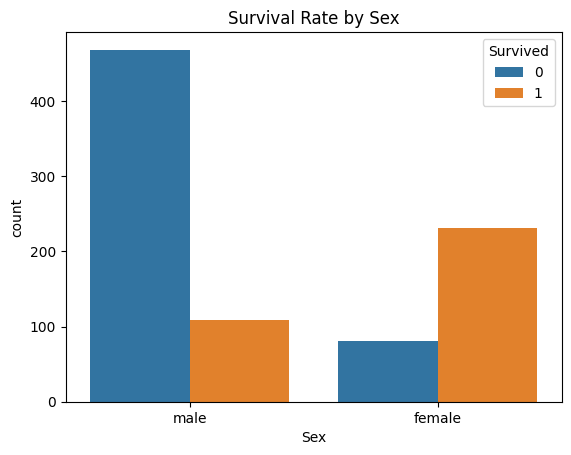

In [37]:
sns.countplot(df, x='Sex', hue='Survived')
plt.title('Survival Rate by Sex')

Text(0.5, 1.0, 'Survival Rate by Pclass')

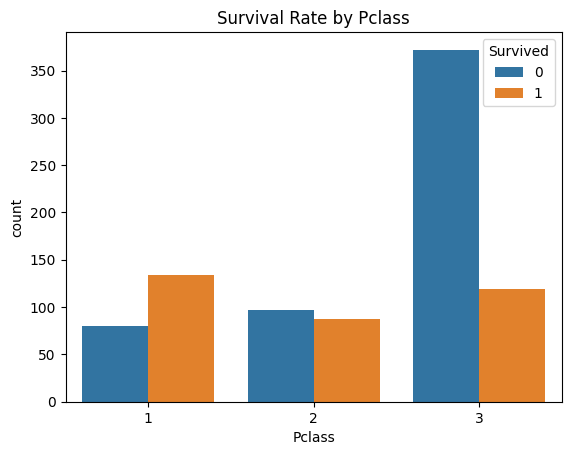

In [38]:
sns.countplot(df, x='Pclass', hue='Survived')
plt.title('Survival Rate by Pclass')

Text(0.5, 1.0, 'Survival Rate by Age')

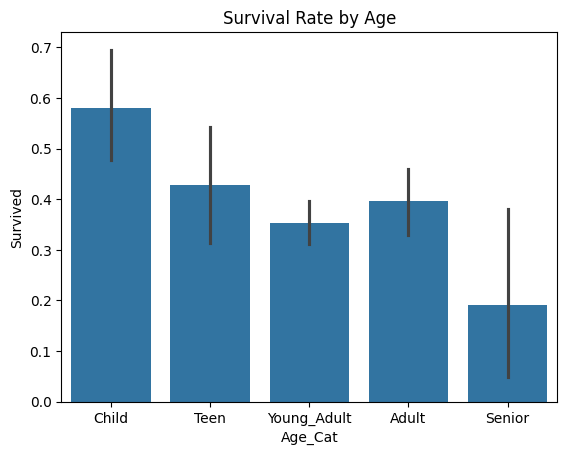

In [39]:
sns.barplot(df, x='Age_Cat', y='Survived')
plt.title('Survival Rate by Age')

The heatmap below was used to check if any other variable would be worth analysing further.

In [40]:
correlacao = df.corr(numeric_only=True)

<Axes: >

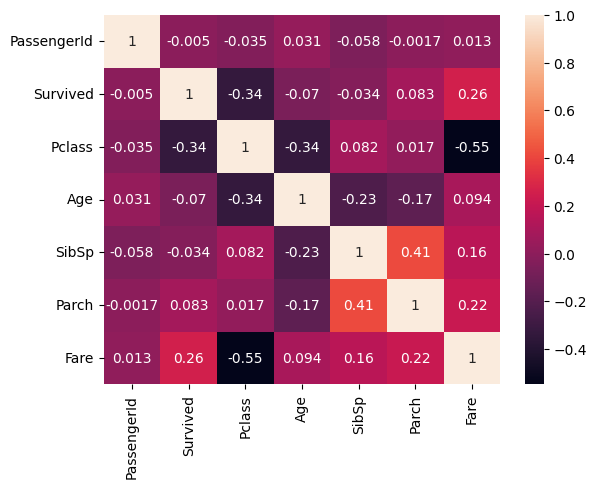

In [41]:
sns.heatmap(correlacao, annot=True)

#Conclusion

After running the analysis it was possible to draw the following conclusions:
1. Average rate of survival was 38%, while for women it was almost the double (74%)
2. The rate of survival was directly related to the age, where for children it was of 58%, decreasing for around 40% in adult ages and plummeting to 22% at senior age.
3. The same pattern was observed for the class which passengers were traveling, with higher rates for first class and lower for third class.